# Data Processing

In [ ]:
import os
import pandas as pd

data = []

for author in os.listdir("../data/Literature"):
    author_path = os.path.join("../data/Literature", author)
    
    if os.path.isdir(author_path):
        for file in os.listdir(author_path):
            if file.endswith(".md"):
                file_path = os.path.join(author_path, file)
                
                with open(file_path, "r", encoding="utf-8") as f:
                    text = f.read()
                
                data.append({
                    "author": author,
                    "filename": file,
                    "text": text
                })

df = pd.DataFrame(data)
print(df.shape)

(111, 3)


In [2]:
import re

#df['tokens'] = df['text'].apply(lambda x: re.findall(r"\b[^\W\d_]+(?:[\''\-][^\W\d_]+)*\b", x.lower()))

azerbaijani_chars = r"[a-zA-ZçÇğĞıİöÖşŞüÜəƏ]"

df['tokens'] = df['text'].apply(lambda x: re.findall(
    rf"\b(?:{azerbaijani_chars}+(?:[\''\-]{azerbaijani_chars}+)*)\b", 
    x.lower()
))

In [3]:
from collections import Counter

all_tokens = [token for tokens in df['tokens'] for token in tokens]
token_counts = Counter(all_tokens)

token_df = pd.DataFrame(token_counts.items(), columns=['token', 'count']).sort_values('count', ascending=False).reset_index(drop=True)
#print(token_df)

In [4]:
#token_df = token_df[token_df['count'] >= 2]
total_token_count = token_df['count'].sum()

In [5]:
print(total_token_count)
print(token_df['count'].mean())

7644775
14.7745391155115


# Task 1: Data Description

In [6]:
print(f"Number of documents: {len(df)}")
print(f"Number of authors: {df['author'].nunique()}")
print(f"Total token count: {token_df['count'].sum()}")
print(f"Number of distinct words: {len(token_df)}")
print(f"Min token count: {token_df['count'].min()}")
print(f"Max token count: {token_df['count'].max()}")
print(f"Mean token count: {token_df['count'].mean():.2f}")

# Frequent words (count >= 100)
frequent = token_df[token_df['count'] >= 100]
print(f"Number of frequent words: {len(frequent)}")

# Rare words (count == 1 or 2)
rare = token_df[token_df['count'] <= 5]
print(f"Number of rare words: {len(rare)}")

Number of documents: 111
Number of authors: 40
Total token count: 7644775
Number of distinct words: 517429
Min token count: 1
Max token count: 148502
Mean token count: 14.77
Number of frequent words: 8917
Number of rare words: 431708


### Word Frquency

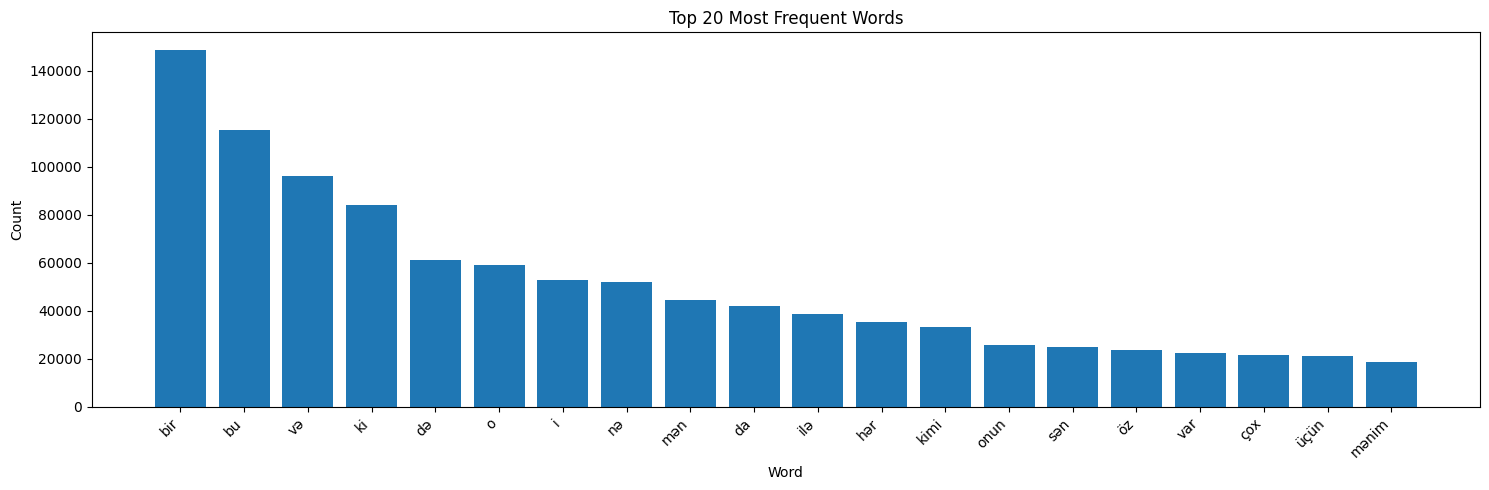

In [7]:
import matplotlib.pyplot as plt

top20 = token_df.head(20)
plt.figure(figsize=(15, 5))
plt.bar(top20['token'], top20['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Term-Document Matrix

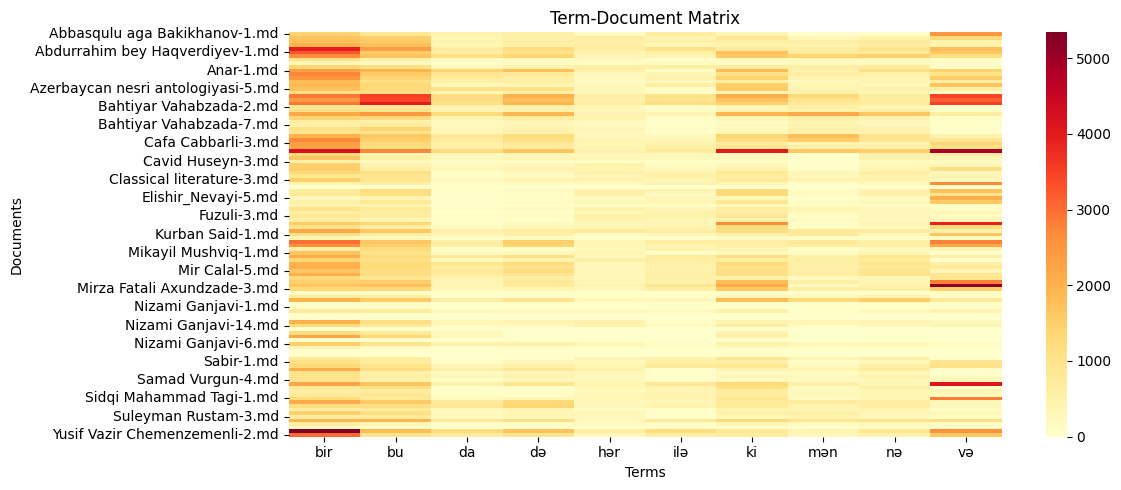

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

df['text_clean'] = df['tokens'].apply(lambda x: ' '.join(x))

vectorizer = CountVectorizer(max_features=10)
tdm = vectorizer.fit_transform(df['text_clean'])

tdm_df = pd.DataFrame(
    tdm.toarray(),
    index=df['filename'],
    columns=vectorizer.get_feature_names_out()
)

# Visualize
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.heatmap(tdm_df, cmap='YlOrRd', annot=False)
plt.title('Term-Document Matrix')
plt.xlabel('Terms')
plt.ylabel('Documents')
plt.tight_layout()
plt.show()

### Word-Word Matrix

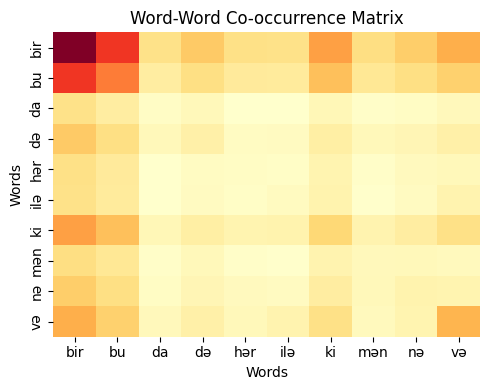

In [9]:
from sklearn.preprocessing import normalize

# Build word-word matrix from TDM
tdm_normalized = normalize(tdm, norm='l2')
wwm = (tdm_normalized.T @ tdm_normalized)

wwm_df = pd.DataFrame(
    wwm.toarray(),
    index=vectorizer.get_feature_names_out(),
    columns=vectorizer.get_feature_names_out()
)

# Visualize
plt.figure(figsize=(5, 4))
sns.heatmap(wwm_df, cmap='YlOrRd', annot=False, cbar=False)
plt.title('Word-Word Co-occurrence Matrix')
plt.xlabel('Words') 
plt.ylabel('Words')
plt.tight_layout()
plt.show()

# Task 2: Word2Vec

### Training

### Results

# Task 3: GloVe

### Training

### Results

# Task 4: GloVe vs Word2Vec

# Task 5: RNN, BiRNN, LSTM

### Libraries

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import f1_score, recall_score
import matplotlib.pyplot as plt
import gc
import os
from gensim.models import Word2Vec

### Reading Input Data

In [ ]:
df = pd.read_csv("/content/dataset.csv")
df = df.dropna(subset=['review', 'sentiment'])
df['sentiment'] = df['sentiment'].astype(float)
print("Shape:", df.shape)
print(df['sentiment'].value_counts())

X_train_val, X_test, y_train_val, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=8
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=8
)
print(f"Train: {len(X_train)} | Validation: {len(X_validation)} | Test: {len(X_test)}")

del df
gc.collect()

lengths = [len(str(x).split()) for x in X_train]
print(np.percentile(lengths, [50, 75, 90, 95, 99]))

### Models

In [ ]:
def build_rnn(input_shape):
    return tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=input_shape),
        tf.keras.layers.SimpleRNN(64, dropout=0.2),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

def build_birnn(input_shape):
    return tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=input_shape),
        tf.keras.layers.Bidirectional(tf.keras.layers.SimpleRNN(64, dropout=0.2)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

def build_lstm(input_shape):
    return tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=input_shape),
        tf.keras.layers.LSTM(64, dropout=0.2),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

os.makedirs('/content/models', exist_ok=True)
results = {}

### Feature Function

In [ ]:
# Single reusable function — builds, trains, evaluates, then cleans up
def run_feature(feat_name, X_tr, X_vl, X_te, input_shape):
    for model_name, build_fn in [('RNN', build_rnn),
                                   ('BiRNN', build_birnn),
                                   ('LSTM', build_lstm)]:
        print(f'\nTraining {model_name} + {feat_name}...')

        model = build_fn(input_shape)
        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

        es = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=2, restore_best_weights=True)

        model.fit(
            X_tr, y_train.values,
            epochs=5, batch_size=8,
            validation_data=(X_vl, y_validation.values),
            callbacks=[es], verbose=1
        )

        _, test_acc = model.evaluate(X_te, y_test.values, verbose=0)
        y_pred = (model.predict(X_te, verbose=0).flatten() >= 0.5).astype(int)
        y_true = y_test.values.astype(int)

        f1     = f1_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)

        results[f'{model_name}+{feat_name}'] = {
            'Accuracy (%)': round(test_acc * 100, 2),
            'F1 Score':     round(f1, 4),
            'Recall':       round(recall, 4)
        }
        model.save(f'/content/models/{model_name}_{feat_name}.keras')
        print(f'→ Acc: {test_acc:.4f} | F1: {f1:.4f} | Recall: {recall:.4f}')

        # Delete model immediately after saving
        del model
        tf.keras.backend.clear_session()
        gc.collect()

### Word2Vec

In [ ]:
def build_rnn(input_shape):
    return tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=input_shape),
        tf.keras.layers.SimpleRNN(64, dropout=0.2),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

def build_birnn(input_shape):
    return tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=input_shape),
        tf.keras.layers.Bidirectional(tf.keras.layers.SimpleRNN(64, dropout=0.2)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

def build_lstm(input_shape):
    return tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=input_shape),
        tf.keras.layers.LSTM(64, dropout=0.2),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

os.makedirs('/content/models', exist_ok=True)
results = {}

### Training

### Running